In [183]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import trange
from bez.cnn.model import Rasterizer
from bez.data import load_normalized
import torch
from meta import ROOT_DIR
from torchvision.transforms import v2
import random

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [184]:
transforms = v2.Compose([
    v2.RandomRotation((-180, 180)),
    v2.RandomCrop(size=(128, 128)),
    v2.RandomHorizontalFlip(p=0.5),
])

N_IMAGES = 4
def load_data_pair(path_x, path_y, device):
    source_x = load_normalized(path_x)
    source_y = 1 - load_normalized(path_y, only_alpha=True)
    return (
        torch.tensor(source_x, device=device, dtype=torch.float32),
        torch.tensor(source_y, device=device, dtype=torch.float32),
    )


sources = [
    (load_normalized(ROOT_DIR / "data" / "train" / f"x_00{i}.png"),
     1-load_normalized(ROOT_DIR / "data" / "train" / f"y_00{i}.png", only_alpha=True))
    for i in range(N_IMAGES)
]

def load_original_dataset(device="cuda"):
    base = ROOT_DIR / "data" / "train"
    return [load_data_pair(base / f"x_00{i}.png", base / f"y_00{i}.png", device) for i in range(N_IMAGES)]



preloaded_sources = load_original_dataset()

def random_labeled_img(batch_size, device="cuda"):
    result_x = []
    result_y = []
    for _ in range(batch_size):
        # Randomly choose one of the preloaded source images.
        source_id = random.randint(0, N_IMAGES - 1)
        source_x_t, source_y_t = preloaded_sources[source_id]
        
        # Keep applying transforms until a valid label (non-zero sum) is produced.
        while True:
            # Concatenate image and label along a new batch dimension.
            input_tensor = torch.cat([
                source_x_t.unsqueeze(0),  # Shape: [1, H, W]
                source_y_t.unsqueeze(0)   # Shape: [1, H, W]
            ], dim=0)  # Combined shape: [2, H, W]
            
            # Apply transforms (ensure transforms support GPU tensors).
            transformed = transforms(input_tensor)
            x, y = transformed[0], transformed[1]
            
            if y.sum() > 0:
                break
        
        # Add noise directly on the GPU.
        noise = 0.02 * torch.randn(128, 128, device=device, dtype=torch.float32)
        x = x + noise
        
        result_x.append(x)
        result_y.append(y)
        
    # Stack and add an extra channel dimension.
    batch_x = torch.stack(result_x).unsqueeze(1)
    batch_y = torch.stack(result_y).unsqueeze(1)
    return batch_x, batch_y

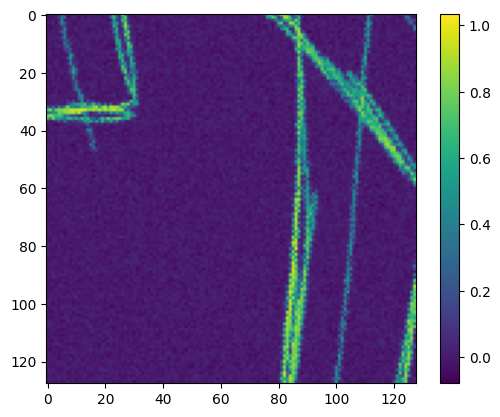

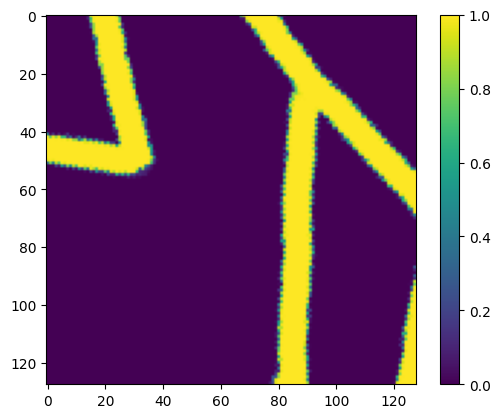

In [185]:
x,y = random_labeled_img(1)
plt.imshow(x.cpu()[0][0])
plt.colorbar()
plt.show()
plt.imshow(y.cpu()[0][0])
plt.colorbar()
plt.show()

In [186]:
def total_variation_loss_l1(image):
    """L1 version of TV loss - often less aggressive"""
    batch_size, channels, height, width = image.size()
    
    tv_h = torch.abs(image[:, :, 1:, :] - image[:, :, :-1, :]).sum()
    tv_w = torch.abs(image[:, :, :, 1:] - image[:, :, :, :-1]).sum()
    
    return (tv_h + tv_w) / (batch_size * channels * height * width)

  0%|          | 0/300 [00:00<?, ?it/s]

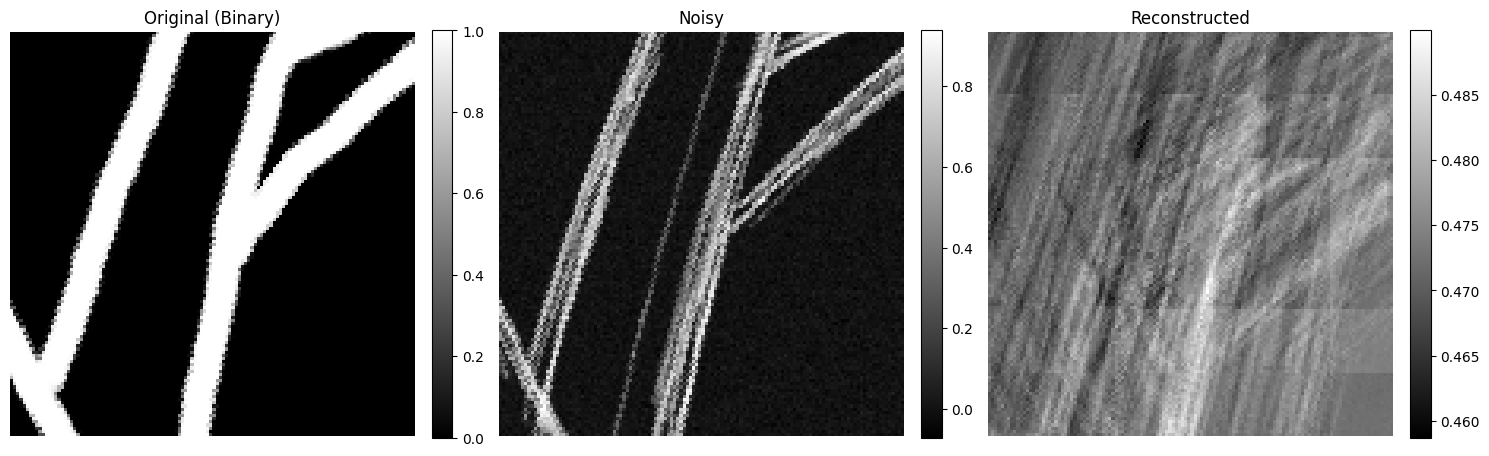

 10%|█         | 30/300 [00:45<06:41,  1.49s/it]

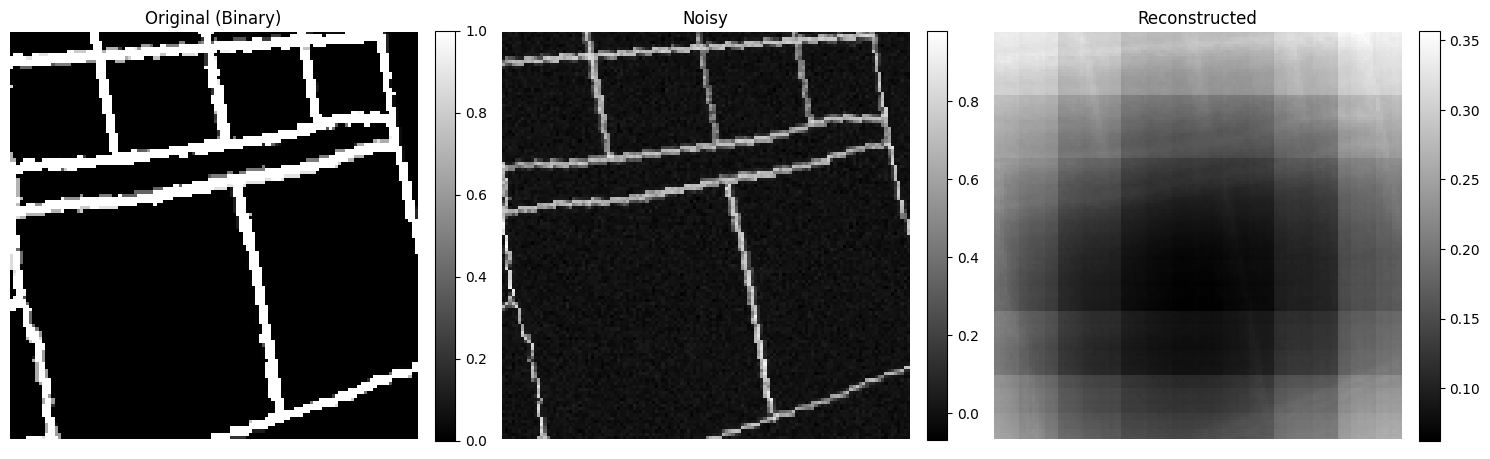

 20%|██        | 60/300 [01:30<06:01,  1.51s/it]

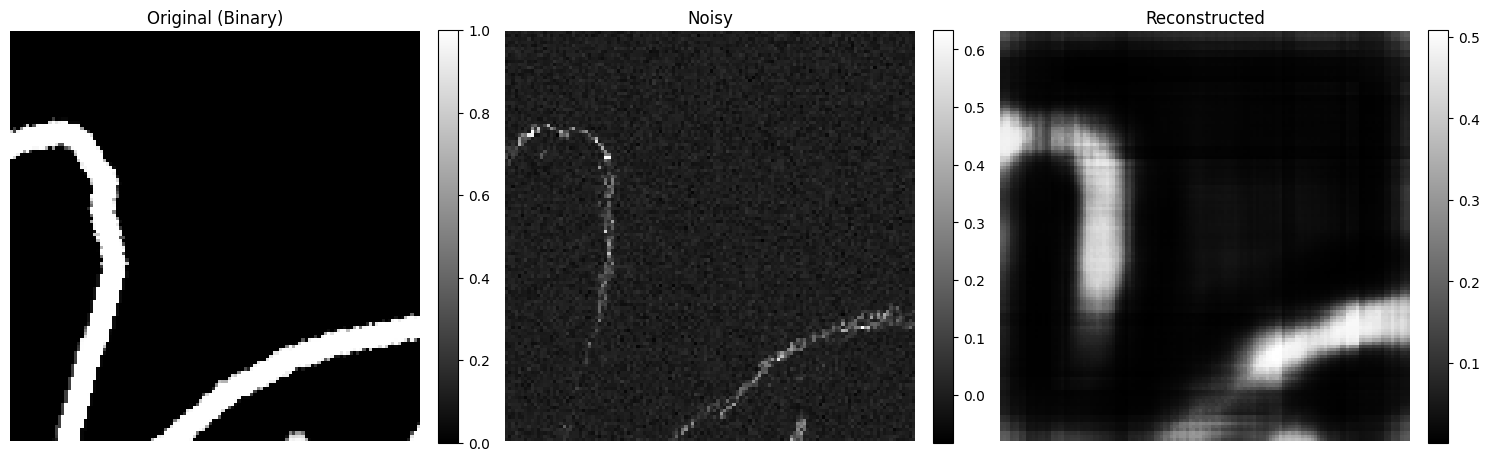

 30%|███       | 90/300 [02:15<05:15,  1.50s/it]

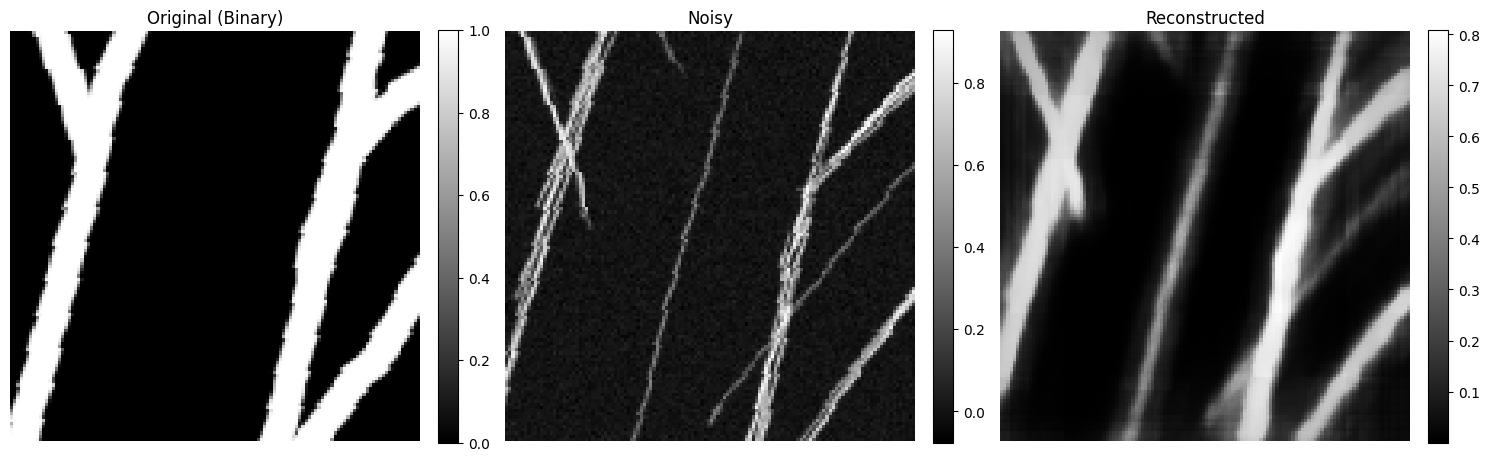

 40%|████      | 120/300 [03:00<04:29,  1.50s/it]

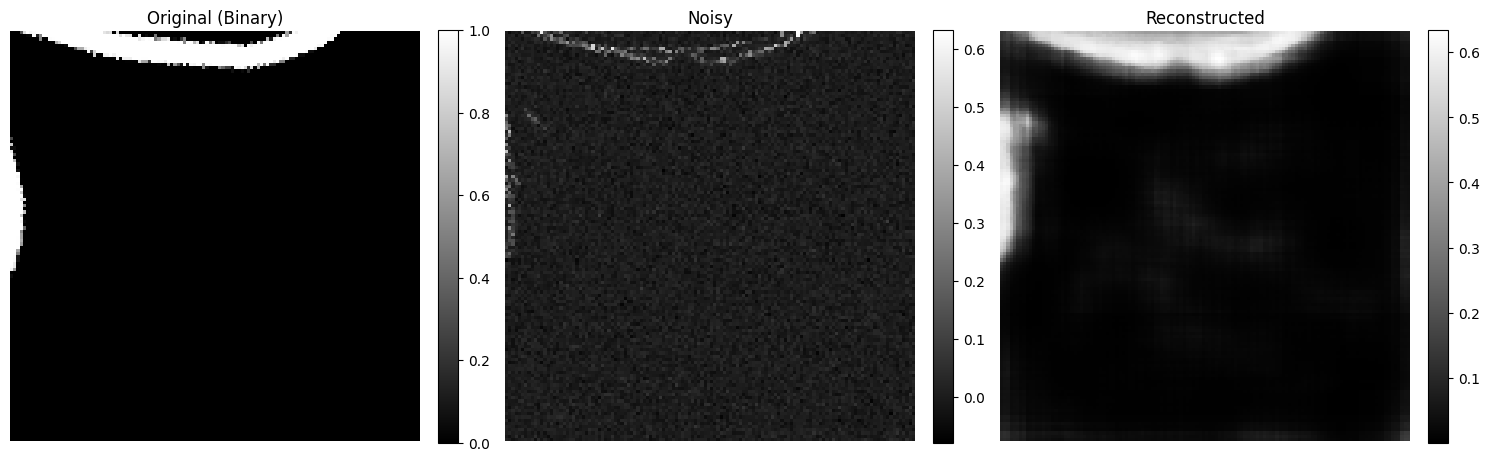

 50%|█████     | 150/300 [03:46<03:44,  1.50s/it]

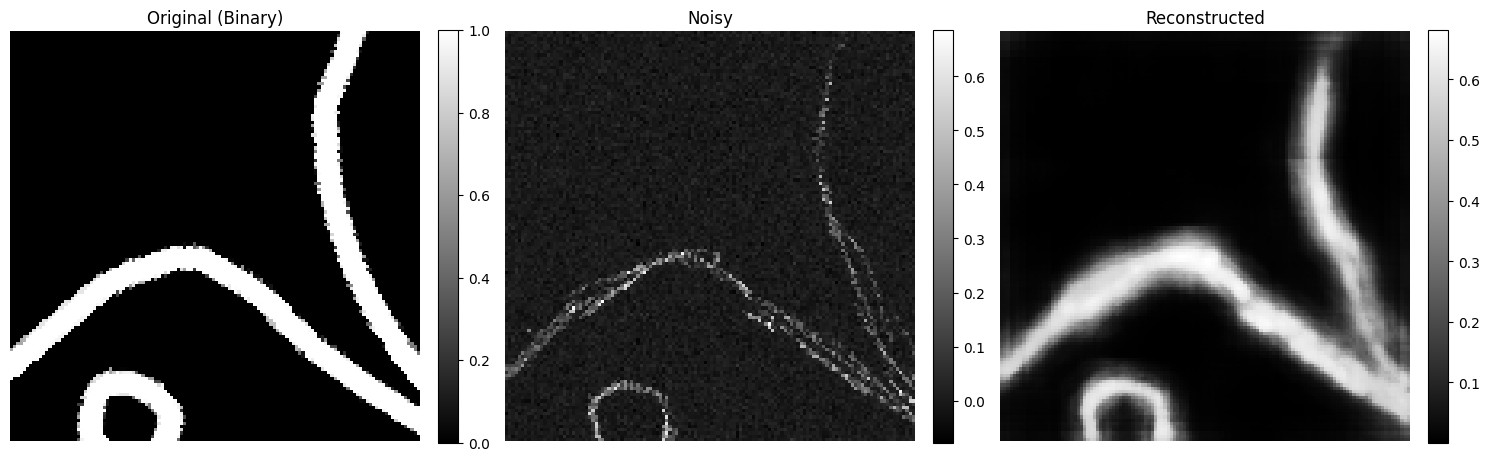

 60%|██████    | 180/300 [04:31<03:00,  1.50s/it]

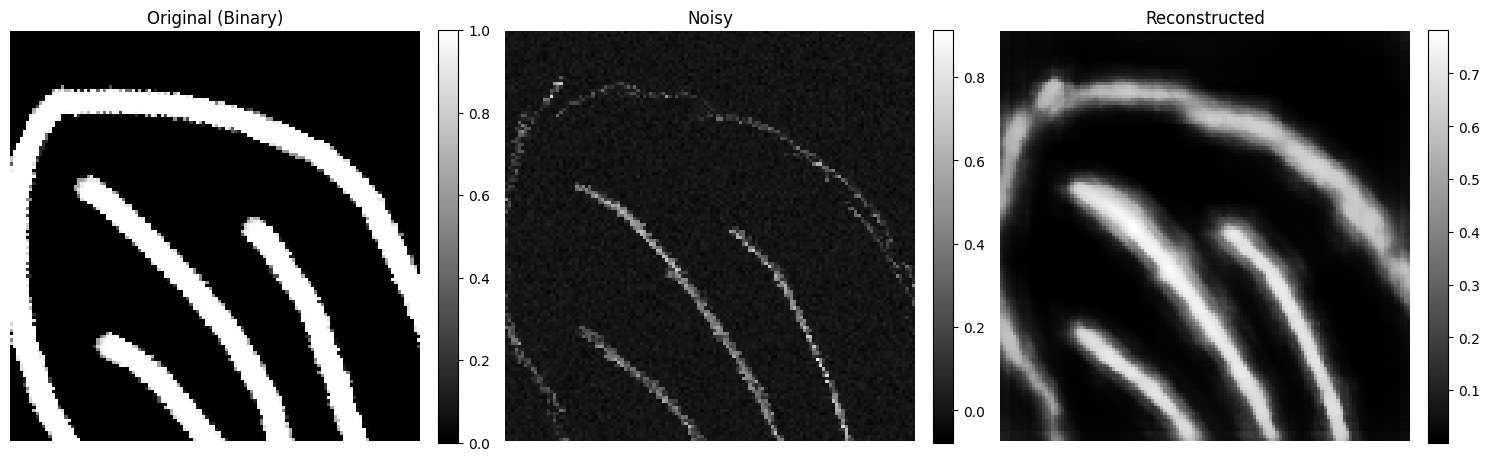

 70%|███████   | 210/300 [05:16<02:14,  1.49s/it]

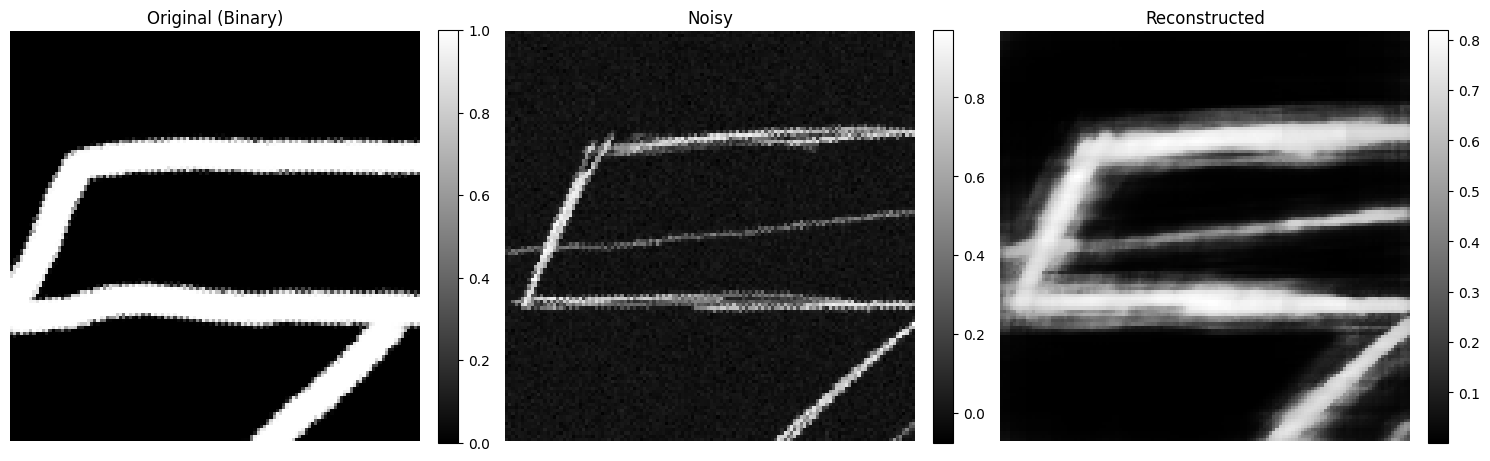

 80%|████████  | 240/300 [06:02<01:29,  1.49s/it]

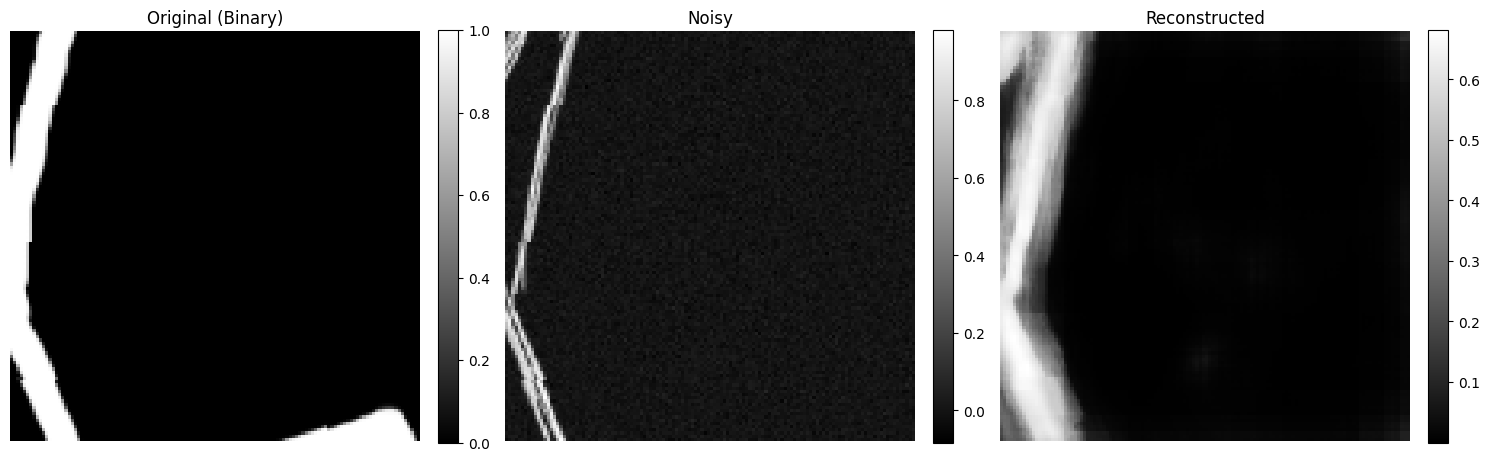

 90%|█████████ | 270/300 [06:47<00:44,  1.50s/it]

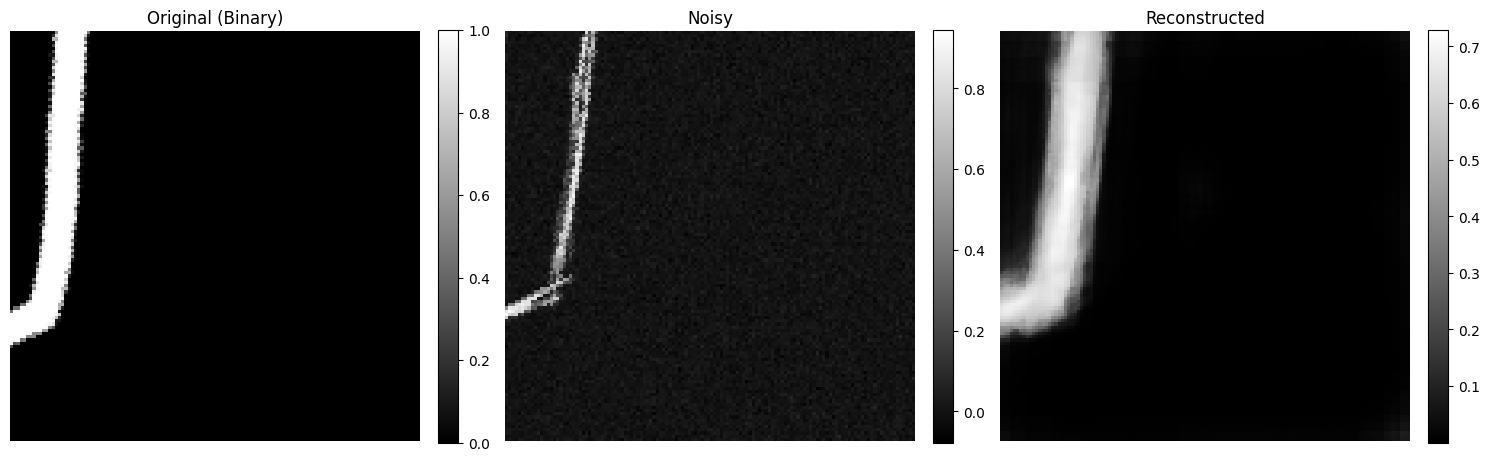

100%|██████████| 300/300 [07:32<00:00,  1.51s/it]


In [191]:
N_iter = 300
tv_weight=1
model = Rasterizer(32).to("cuda")
criterion = torch.nn.BCELoss()
opti = torch.optim.AdamW(model.parameters(), lr=.5e-2)
losses = []

for step in trange(N_iter):
    # Generate synthetic data
    x, y = random_labeled_img(300)

    # Training step
    opti.zero_grad()
    y_pred = model.forward(x)
    pred_loss = criterion(y_pred, y)
    tv_loss = total_variation_loss_l1(y_pred)
    loss = pred_loss + tv_weight * tv_loss
    loss.backward()
    opti.step()

    # Display triplets every 20 steps
    if step % 30 == 0:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
                                                                                             # Original (binary)
         # Original (binary)
        im1 = axes[0].imshow(y[0][0].detach().cpu(), cmap='gray')
        axes[0].set_title('Original (Binary)')
        axes[0].axis('off')
        plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

        # Noisy
        im2 = axes[1].imshow(x[0][0].detach().cpu(), cmap='gray')
        axes[1].set_title('Noisy')
        axes[1].axis('off')
        plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

        # Reconstructed
        im3 = axes[2].imshow(y_pred[0][0].detach().cpu(), cmap='gray')
        axes[2].set_title('Reconstructed')
        axes[2].axis('off')
        plt.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

        plt.tight_layout()
        plt.show()

    losses.append(loss.detach().cpu())

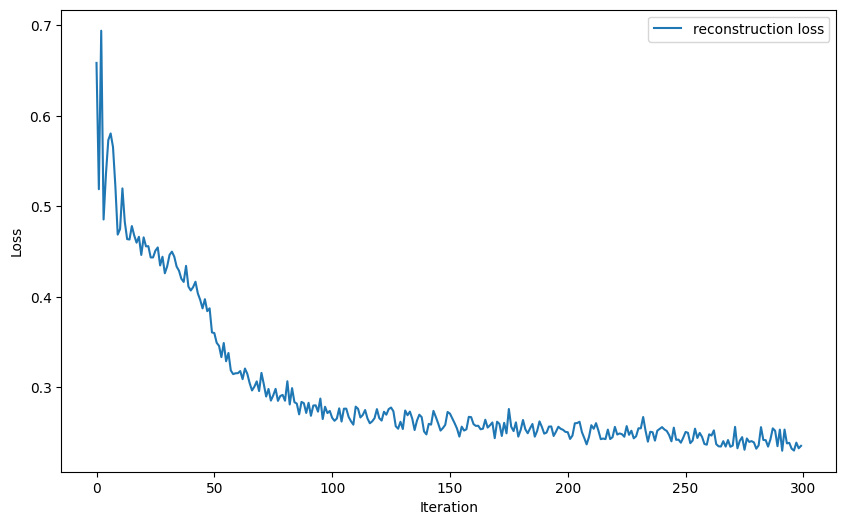

In [192]:
plt.figure(figsize=(10, 6))
plt.plot(range(len(losses)), losses, label="reconstruction loss")
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.legend()
plt.show()

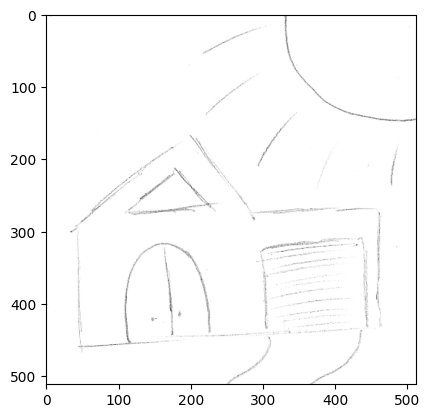

In [193]:
test = load_normalized(ROOT_DIR / "data/sketches/house.png")
plt.imshow(test, cmap="binary")
plt.show()

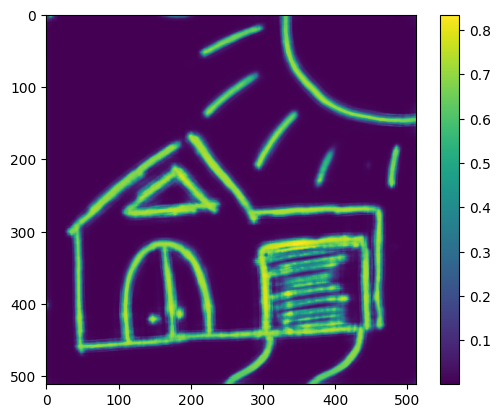

In [196]:
pred = model.forward(torch.tensor(test).cuda().unsqueeze(0))
plt.imshow(pred.detach().cpu()[0])
plt.colorbar()
plt.show()

In [198]:
dummy_input = torch.rand((1, 256, 256), dtype=torch.float32)
torch.onnx.export(
    model.cpu(),
    (dummy_input,),
    ROOT_DIR / "src" / "bez" / "cnn" / "model.onnx",
    input_names=["input"],
    output_names=["output"],
    export_params=True,
    dynamic_axes={
        "input": {1: "height", 2: "width"},  # Variable H, W
        "output": {1: "height", 2: "width"},  # Variable H, W
    },
)
